PART A: K-MEANS CLUSTERING


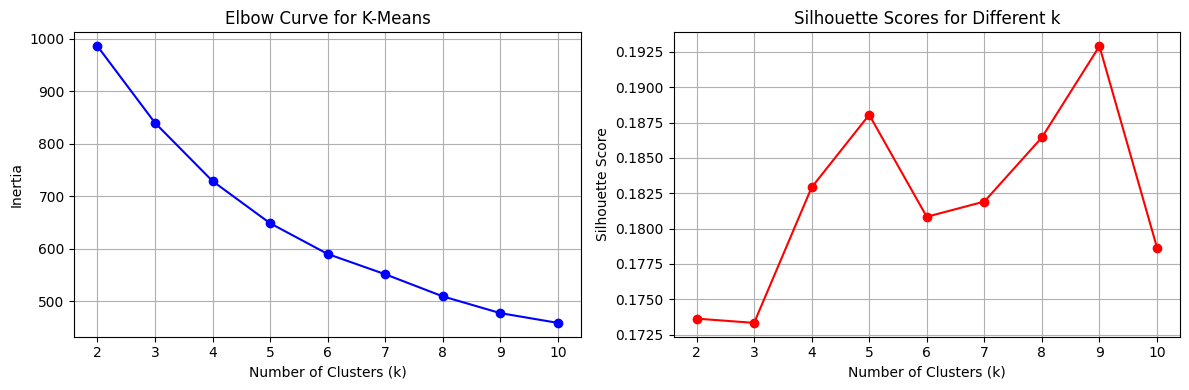

Optimal k based on silhouette score: 9


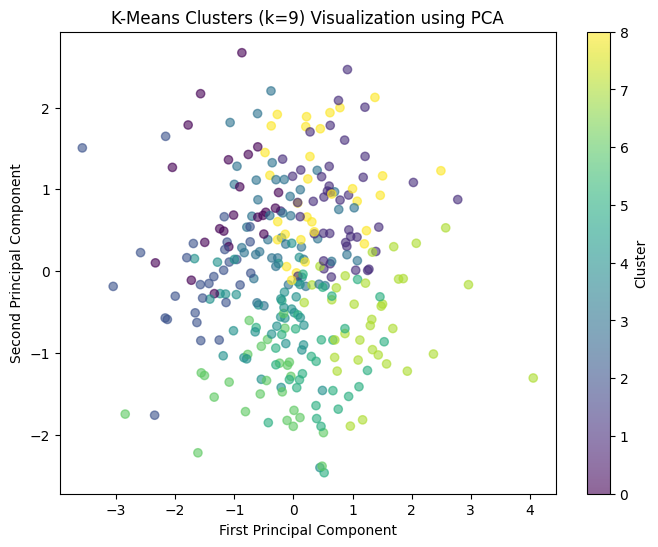


PART B: HIERARCHICAL CLUSTERING


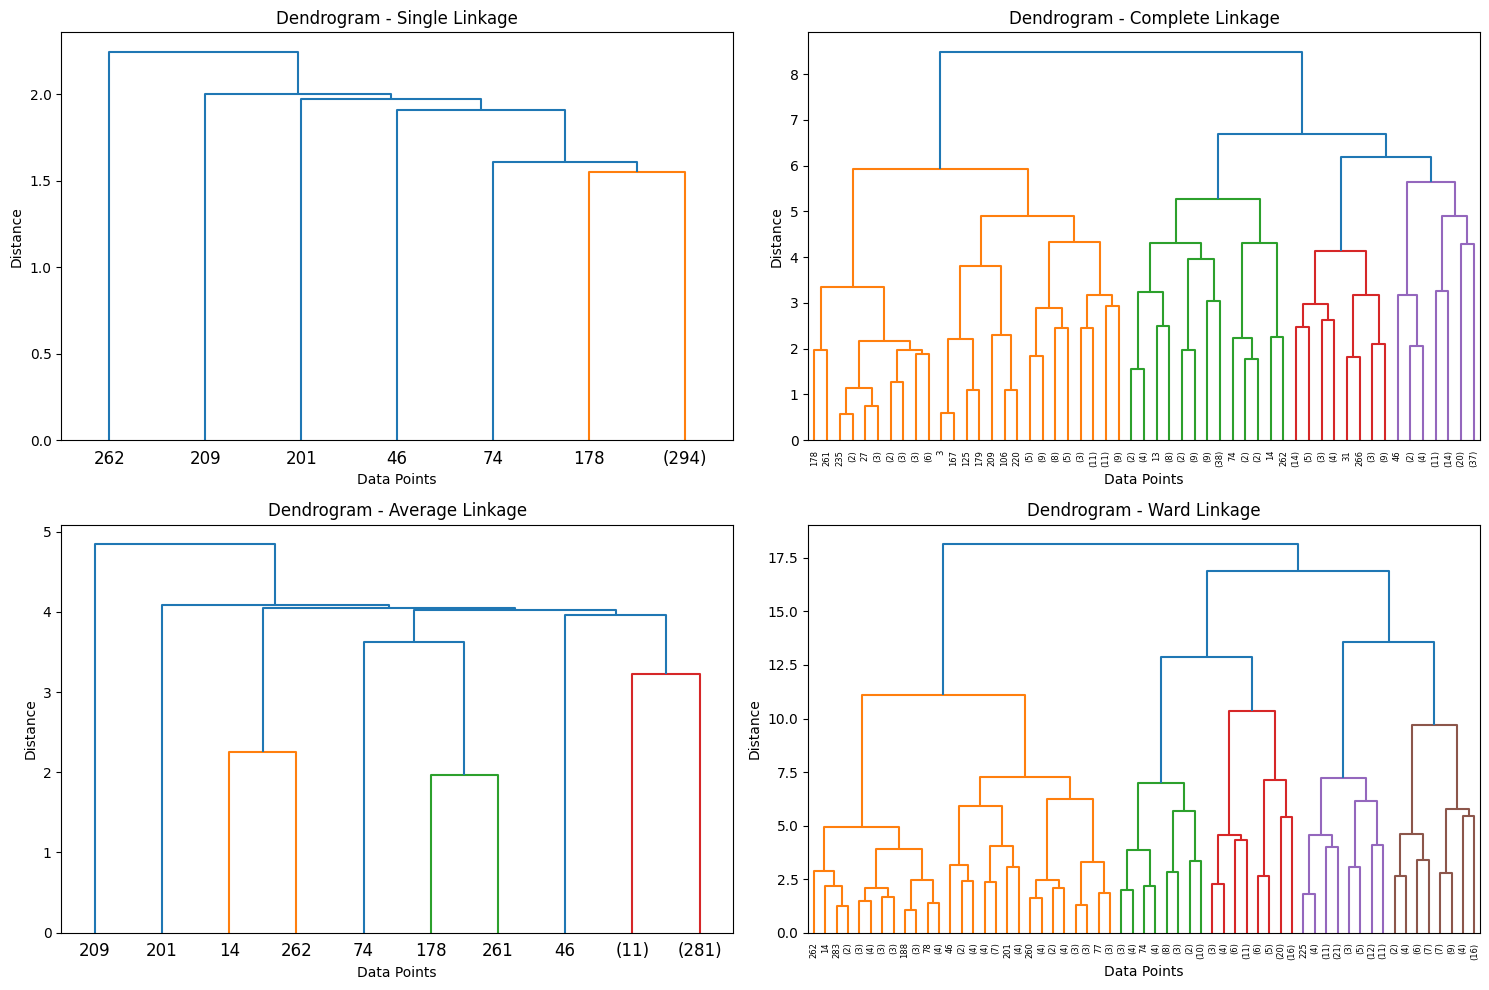

Single Linkage - Silhouette Score: 0.055
Complete Linkage - Silhouette Score: 0.120
Average Linkage - Silhouette Score: 0.005
Ward Linkage - Silhouette Score: 0.159


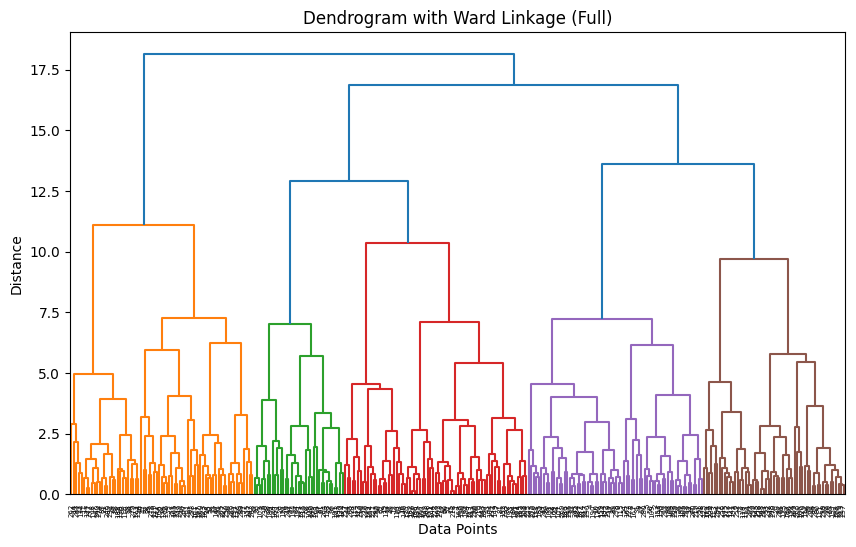


PART C: COMPARISON

Computation Time Comparison:
K-Means (k=9): 0.0776 seconds
Hierarchical (Ward, k=9): 0.0065 seconds

Cluster Characteristics Comparison:
----------------------------------------

K-Means Cluster Centers (Original Scale):
Cluster 0:
  Annual_Income: 47487.49
  Spending_Score: 46.14
  Age: 52.88
  Purchase_Frequency: 3.04
Cluster 1:
  Annual_Income: 53297.21
  Spending_Score: 19.92
  Age: 44.46
  Purchase_Frequency: 11.02
Cluster 2:
  Annual_Income: 39246.75
  Spending_Score: 78.65
  Age: 47.34
  Purchase_Frequency: 6.32
Cluster 3:
  Annual_Income: 33041.54
  Spending_Score: 42.55
  Age: 42.61
  Purchase_Frequency: 13.96
Cluster 4:
  Annual_Income: 46698.99
  Spending_Score: 38.14
  Age: 28.80
  Purchase_Frequency: 5.55
Cluster 5:
  Annual_Income: 69115.87
  Spending_Score: 65.10
  Age: 35.42
  Purchase_Frequency: 9.24
Cluster 6:
  Annual_Income: 42512.62
  Spending_Score: 82.88
  Age: 29.21
  Purchase_Frequency: 12.87
Cluster 7:
  Annual_Income: 62180.40
  Spending_

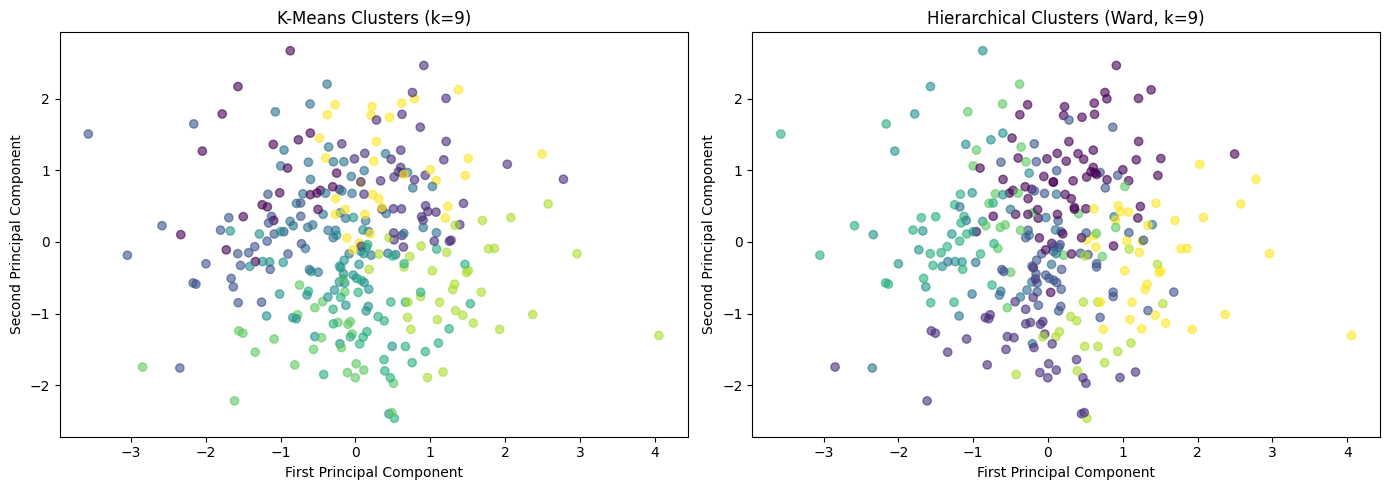


BUSINESS INTERPRETATION


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import time
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)
n_customers = 300

data = {
    'Annual_Income': np.random.normal(50000, 15000, n_customers),
    'Spending_Score': np.random.normal(50, 25, n_customers),
    'Age': np.random.normal(40, 12, n_customers),
    'Purchase_Frequency': np.random.normal(10, 5, n_customers)
}

df = pd.DataFrame(data)

print("=" * 50)
print("PART A: K-MEANS CLUSTERING")
print("=" * 50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-Means')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.grid(True)

plt.tight_layout()
plt.show()

optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means Clusters (k={optimal_k}) Visualization using PCA')
plt.colorbar(label='Cluster')
plt.show()

print("\n" + "=" * 50)
print("PART B: HIERARCHICAL CLUSTERING")
print("=" * 50)

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    linkage_matrix = linkage(X_scaled, method=method)
    dendrogram(linkage_matrix, ax=axes[idx], truncate_mode='level', p=5)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    axes[idx].set_xlabel('Data Points')
    axes[idx].set_ylabel('Distance')

plt.tight_layout()
plt.show()

for method in linkage_methods:
    if method == 'ward':
        agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    else:
        agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)

    agg_labels = agg_clustering.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, agg_labels)
    print(f"{method.capitalize()} Linkage - Silhouette Score: {sil_score:.3f}")

linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram with Ward Linkage (Full)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

print("\n" + "=" * 50)
print("PART C: COMPARISON")
print("=" * 50)

print("\nComputation Time Comparison:")

start_time = time.time()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start_time
print(f"K-Means (k={optimal_k}): {kmeans_time:.4f} seconds")

start_time = time.time()
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_time = time.time() - start_time
print(f"Hierarchical (Ward, k={optimal_k}): {hierarchical_time:.4f} seconds")

print("\nCluster Characteristics Comparison:")
print("-" * 40)

df['KMeans_Cluster'] = kmeans_labels
df['Hierarchical_Cluster'] = hierarchical_labels

print("\nK-Means Cluster Centers (Original Scale):")
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)

for i in range(optimal_k):
    print(f"Cluster {i}:")
    for j, col in enumerate(df.columns[:4]):
        print(f"  {col}: {kmeans_centers[i, j]:.2f}")

print("\nHierarchical Cluster Statistics:")
for i in range(optimal_k):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    print(f"\nCluster {i} (size: {len(cluster_data)}):")
    for col in df.columns[:4]:
        print(f"  {col} - Mean: {cluster_data[col].mean():.2f}, Std: {cluster_data[col].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title(f'K-Means Clusters (k={optimal_k})')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].set_title(f'Hierarchical Clusters (Ward, k={optimal_k})')

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("BUSINESS INTERPRETATION")
print("=" * 50)